In [1]:
%cd ../../

/leonardo_work/IscrC_LR4LSDS/encoderops


In [2]:
from wandb.apis.public import Api
from pathlib import Path
from datetime import datetime

from src.model import EvolutionOperator
from src.data import DESRESDataModule
from src.configs import TrainerArgs, DESRESDataArgs # noqa

#from src.utils import get_residuals

import torch
import scipy.linalg
import numpy as np
import pandas as pd

In [3]:
def check_date(date_str, cutoff_date = datetime(2025, 11, 10)):
   return datetime.strptime(date_str.rstrip('Z'), '%Y-%m-%dT%H:%M:%S.%f') > cutoff_date

def get_residuals(l, Q, cov_X, cov_Y, cov_XY):
    # Compute the residuals as defined in Eq. 3.2 of M. Colbrook's ResDMD
    # https://doi.org/10.1017/jfm.2022.1052

    res2 = []
    for i, eig in enumerate(l):
        q = Q[:, i]
        num = np.vdot(q, (cov_Y - eig * cov_XY.T - eig.conj() * cov_XY + np.abs(eig)**2 * cov_X) @ q)
        den = np.vdot(q, cov_X @ q)
        res2.append(num / den)

    return np.sqrt(np.array(res2))

@torch.no_grad()
def compute_eig_residuals(model: EvolutionOperator, reg:float=1e-4):
    if model.forecast:
        d = model.trainer_args.latent_dim + model.encoder_args["input_shape"]
    else:
        d = model.trainer_args.latent_dim
    cov_X = model.covariances.cov_X.numpy(force=True)
    cov_Y = model.covariances.cov_Y.numpy(force=True)
    regularizer = reg * np.eye(d)
    cross_cov = model.covariances.cov_XY.numpy(force=True)
    l, Q = scipy.linalg.eig(cross_cov, cov_X + regularizer)
    residuals = get_residuals(l, Q, cov_X, cov_Y, cross_cov)
    return residuals, l

In [4]:
def load_runs_history(project_id: str = "encoderops-2JOF"):
    print(f"Loading {project_id} runs")
    runs = Api().runs(
    path=f"pietronvll/{project_id}",
    )
    runs = list(runs)
    ckpt_path = lambda run_id: Path(f"logs/{project_id}/{run_id}/checkpoints/last.ckpt")
    data = {}
    residuals = {}
    for run in runs:
        if check_date(run.metadata['startedAt']):
            model = EvolutionOperator.load_from_checkpoint(ckpt_path(run.id))
            history = run.scan_history()
            data_run = []
            for step in history:
                data_run.append(step)
            data[model.trainer_args.latent_dim] = pd.DataFrame(data_run)
            residuals[model.trainer_args.latent_dim] = compute_eig_residuals(model)
    data = sorted(data.items())
    residuals = sorted(residuals.items())
    # Sorting residuals
    latent_dims, residuals_and_eigs = list(zip(*residuals))
    res, eigs = list(zip(*residuals_and_eigs))

    sorters = [np.argsort(np.abs(eig)) for eig in eigs]
    top_4_residuals = []
    for i in range(1, 5):
        leading_residual = [error[selector[-i]].real for (error, selector) in zip(res, sorters)]
        top_4_residuals.append(leading_residual)
        #leading_eig = [val[selector[-i]].real for (val, selector) in zip(eigs, sorters)]
    top_4_residuals = np.array(top_4_residuals)
    return data, top_4_residuals, latent_dims

In [5]:
report = {}
for project_suffix in ['', '-S', '-L']:
    project_id = "encoderops-2JOF" + project_suffix
    report[project_id] = load_runs_history(project_id)

Loading encoderops-2JOF runs
Loading encoderops-2JOF-S runs
Loading encoderops-2JOF-L runs


In [40]:
import matplotlib.pyplot as plt
import matplotx
import json
def plot_color_palette(color_dict: dict):
    """
    Plots the color dictionary (e.g., {"gray": ["#fcfc..", ...]}) using Matplotlib.
    
    Args:
        color_dict: Dictionary where keys are color names (str) and values are 
                    lists of hex color codes (list[str]).
    """
    if not color_dict:
        print("The color dictionary is empty.")
        return

    # Prepare data
    color_names = list(color_dict.keys())
    num_colors = len(color_names)
    shades_per_color = len(next(iter(color_dict.values())))

    # Create figure and axes
    fig_height = num_colors * 0.5  # Adjust height based on number of color families
    fig, ax = plt.subplots(figsize=(10, fig_height))
    fig.subplots_adjust(hspace=0, wspace=0)

    # Plot each color family
    for i, name in enumerate(color_names):
        colors = color_dict[name]
        
        # Create a horizontal strip for the color family
        for j, hex_code in enumerate(colors):
            ax.barh(
                y=i,              # Vertical position (color family index)
                width=1.,          # Width of a single shade block
                left=j,           # Starting position for this shade
                color=hex_code,
                height=1.0,       # Height of the strip
                edgecolor='none'
            )
            ax.text(x =j + 0.5, y=i, s=j, va='center', ha='center', fontsize=8, color='white' if j > shades_per_color / 2 else 'black')

    # Configure axes
    ax.set_yticks(range(num_colors))
    ax.set_yticklabels(color_names)
    ax.set_xticks([])
    ax.set_xlabel('Shade Index (1 to 12)')
    
    # Clean up and display
    ax.set_ylim(-0.5, num_colors - 0.5) # Set limits to center the bars
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    plt.tight_layout()
    plt.show()

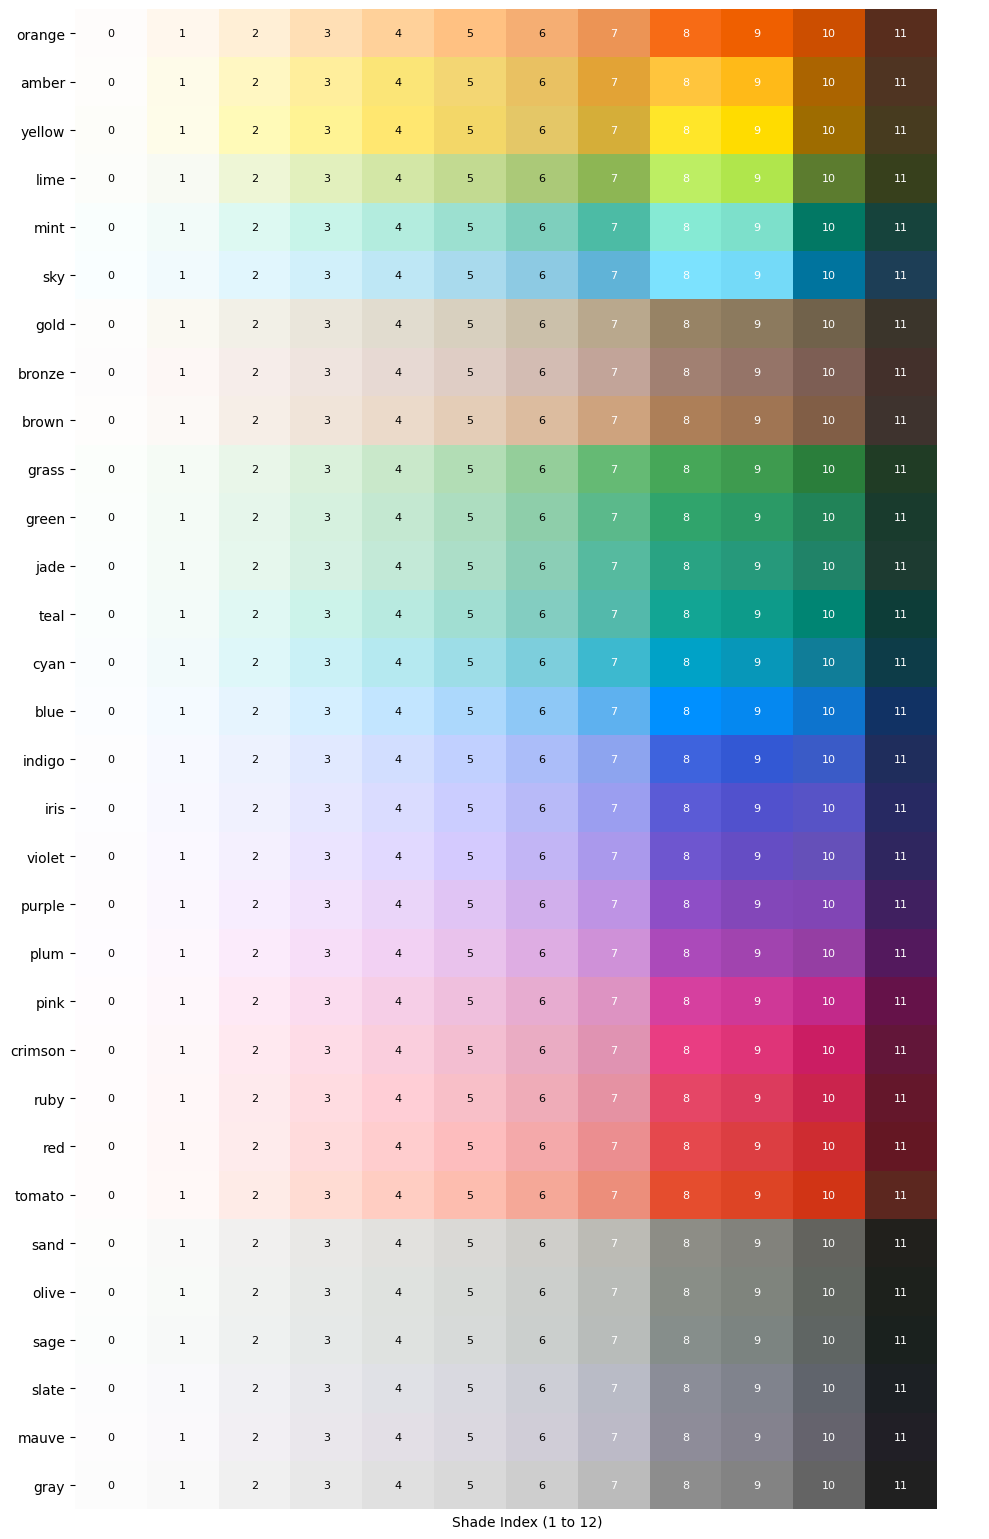

In [41]:
with open("/leonardo_work/IscrC_LR4LSDS/encoderops/exps/trpcage/colors.json") as f:
    color_palette = json.load(f)
plot_color_palette(color_palette)

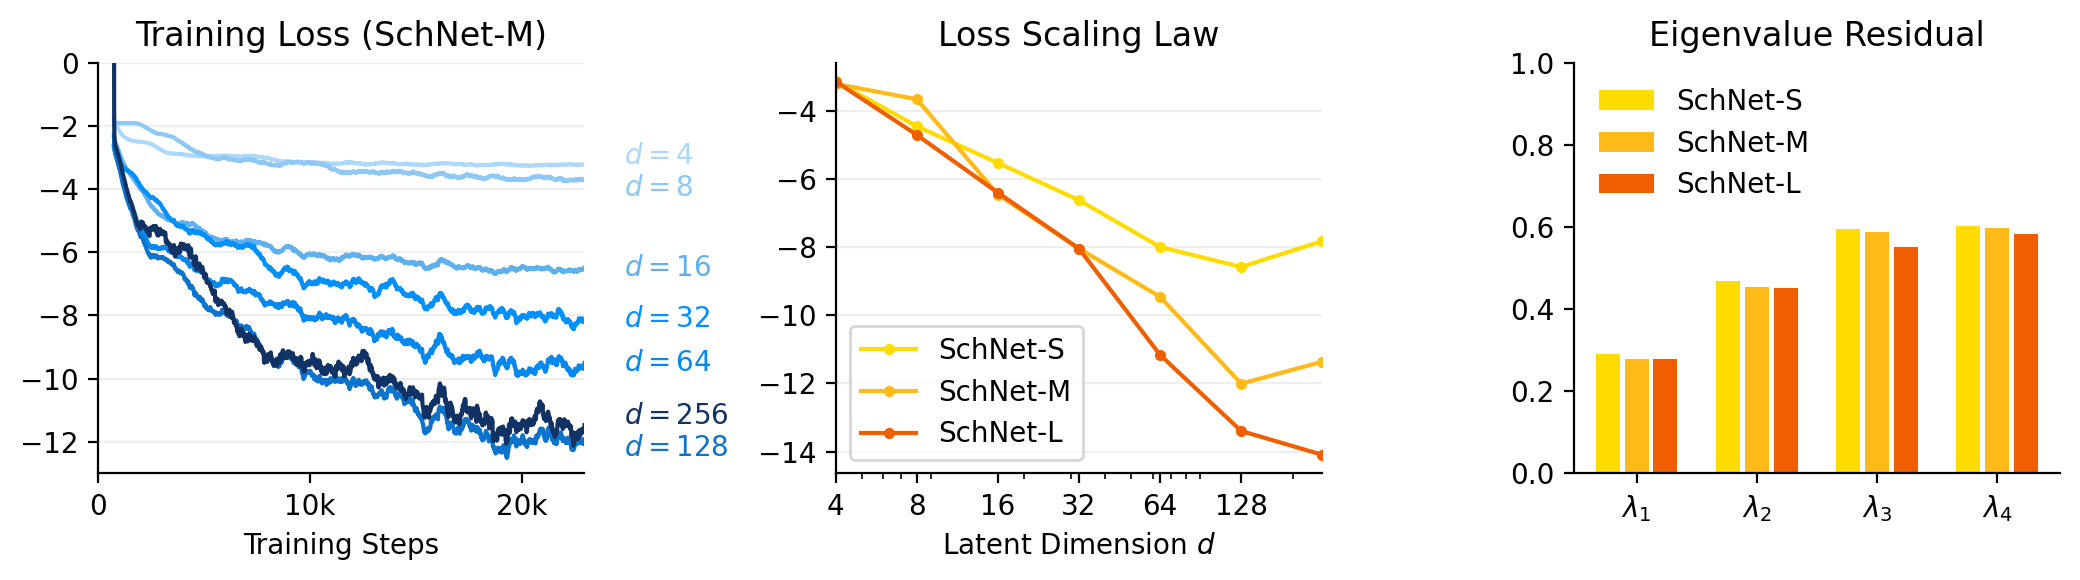

In [59]:
from matplotlib.patches import FancyBboxPatch
fig, axs = plt.subplots(ncols=3, figsize=(10.5,3), dpi=200)
# Loss
project_id = "encoderops-2JOF"
data, top_4_residuals, latent_dims = report[project_id]
ax = axs[0]
for k, (feats, summary) in enumerate(data):
    if feats < 500:
        ax.plot(summary['trainer/global_step'], -summary['train_loss'].rolling(75).mean(), color=color_palette['blue'][k + 5], label=fr"$d = {feats}$")
matplotx.line_labels(ax=ax, min_label_distance=1)
ax.set_ylim(-13, 0)
ax.margins(x=0)
ax.set_xlabel('Training Steps')
ax.set_xticks([0, 10000, 20000], [0 , '10k', '20k'])
ax.grid(axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
#ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['bottom'].set_visible(False)
ax.set_title(r'Training Loss (SchNet-M)')
# Residuals 
ax = axs[2]
bw = 0.2
for size, color, offset in zip(['small', 'medium', 'large'], ['yellow', 'amber', 'orange'], [-bw, 0, bw]):
    _, top_4_residuals, _ = report[project_id + {'small':'-S', 'medium':'', 'large':'-L'}[size]]
    for k, y in enumerate(top_4_residuals):
        for d_idx, latent_dim in enumerate(latent_dims):
            if latent_dim == 128:    
                ax.bar(k+offset*1.2, y[d_idx], width=bw, color=color_palette[color][9], align='center', label=f'SchNet-{size[0].capitalize()}' if k==0 else None)
ax.set_xticks(range(4), [fr"$\lambda_{i+1}$" for i in range(4)])
ax.set_title("Eigenvalue Residual")
ax.spines['top'].set_visible(False)
#ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc= 'upper left')
#ax.spines['bottom'].set_visible(False)
# for k, y in enumerate(top_4_residuals):
#     ax.plot(latent_dims[:6], y[:6], color=color_palette['gray'][-(k + 2)], label=fr"$\lambda_{k + 1}$")
# matplotx.line_labels(ax=ax, min_label_distance=0.1)
# ax.set_ylim(0, 1)
# ax.margins(x=0)
# ax.set_xscale('log')
# ax.grid(axis='y')
# ax.spines['top'].set_visible(False)
# ax.spines['left'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
# ax.set_xticks([2**(k + 2) for k in range(6)], [2**(k+2) for k in range(6)])
# ax.set_xlabel(r'Latent Dimension $d$')
# ax.set_title('Eigenvalue residuals (SchNet-M)')
# Scaling
ax = axs[1]
final_losses = {}
for k, (data, _, _) in report.items():
    _feats = []
    _losses = []
    for feats, summary in data:
        if feats < 500:
            _feats.append(feats)
            _losses.append(-summary['train_loss'].rolling(50).mean().values[-1])
    k = k.replace("encoderops-2JOF", "SchNet")
    if k[-1] == 't':
        k = k + "-M"
    final_losses[k] = [_feats, _losses]
final_losses['SchNet-S'].append(color_palette['yellow'][9])
final_losses['SchNet-M'].append(color_palette['amber'][9])
final_losses['SchNet-L'].append(color_palette['orange'][9])
for k, size in enumerate(['SchNet-S', 'SchNet-M', 'SchNet-L']):
    feats, losses, color = final_losses[size]
    ax.plot(feats, losses, '.-', color=color, label =size)

#matplotx.line_labels(ax=ax, min_label_distance=0.1)
ax.margins(x=0)
ax.set_xscale('log')
ax.grid(axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
#ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['bottom'].set_visible(False)
ax.set_xticks([2**(k + 2) for k in range(6)], [2**(k+2) for k in range(6)])
ax.set_xlabel(r'Latent Dimension $d$')
ax.set_title('Loss Scaling Law')
ax.legend(frameon=True, loc='lower left')
fig.tight_layout()
fig.savefig("exps/trpcage/schnet_ablations.svg")
#ax.set_title(r'$-\varepsilon(\varphi, P)$')

In [72]:
model_params = lambda model: sum(p.numel() for p in model.parameters())

In [74]:
from src.modules import SchNetModel

In [94]:
schnet_S = {'n_out': 32,
 'cutoff': 7.0,
 'atomic_numbers': [6, 7, 8],
 'n_bases': 16,
 'n_layers': 2,
 'n_filters': 16,
 'n_hidden_channels': 32}
print(f"schnet-S : {model_params(SchNetModel(**schnet_S))}")
schnet_M = {'n_out': 32,
 'cutoff': 7.0,
 'atomic_numbers': [6, 7, 8],
 'n_bases': 16,
 'n_layers': 3,
 'n_filters': 32,
 'n_hidden_channels': 64}
print(f"schnet-M : {model_params(SchNetModel(**schnet_M))}")
schnet_L = {'n_out': 32,
 'cutoff': 7.0,
 'atomic_numbers': [6, 7, 8],
 'n_bases': 16,
 'n_layers': 3,
 'n_filters': 64,
 'n_hidden_channels': 128}
print(f"schnet-L : {model_params(SchNetModel(**schnet_L))}")

schnet-S : 6480
schnet-M : 33088
schnet-L : 125536
